In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregar os dados corrigidos do Iris do sklearn
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

# 2. Separar dados de treino e teste
# 'target' é a coluna que queremos prever, então a removemos de X para usarmos como y
X = df.drop('target', axis=1) # Características (medidas)
y = df['target']              # Alvo (espécie da flor)

# 3. Dividir os dados em 2/3 para treino e 1/3 para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)

In [2]:
# ----- PARTE 1: Caminho de poda (ccp_alpha) -----
# O sklearn nos dá uma função que calcula todos os alphas possíveis e a "impureza total das folhas" correspondente a cada um.
modelo_base = DecisionTreeClassifier(criterion='entropy', random_state=42)
path = modelo_base.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(f"Quantidade de valores de alpha candidatos: {len(ccp_alphas)}")
print(f"Alphas: {ccp_alphas}")

Quantidade de valores de alpha candidatos: 8
Alphas: [0.         0.02754888 0.02754888 0.0361848  0.04194338 0.07303945
 0.44168669 0.89317346]



Melhor ccp_alpha encontrado: 0.0419
Acurácia média (CV) nesse alpha: 92.00%


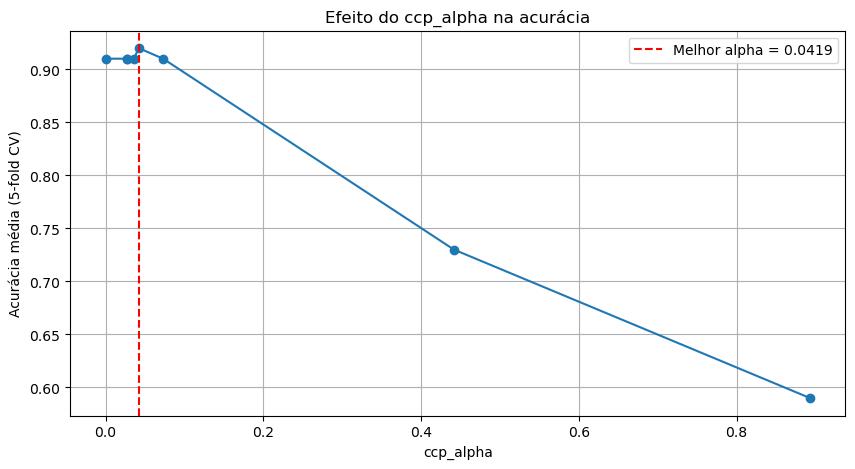

In [3]:
# ----- PARTE 2: Escolher o melhor alpha via validação cruzada -----
# Para cada alpha, treinamos uma árvore e medimos sua performance média em 5-fold cross-validation APENAS no conjunto de TREINO.
scores_por_alpha = []
for alpha in ccp_alphas:
    modelo = DecisionTreeClassifier(criterion='entropy', ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(modelo, X_train, y_train, cv=5)
    scores_por_alpha.append(scores.mean())

melhor_alpha = ccp_alphas[np.argmax(scores_por_alpha)]
print(f"\nMelhor ccp_alpha encontrado: {melhor_alpha:.4f}")
print(f"Acurácia média (CV) nesse alpha: {max(scores_por_alpha) * 100:.2f}%")

# Plotar o efeito do alpha
plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, scores_por_alpha, marker='o')
plt.axvline(melhor_alpha, color='red', linestyle='--', label=f'Melhor alpha = {melhor_alpha:.4f}')
plt.xlabel("ccp_alpha")
plt.ylabel("Acurácia média (5-fold CV)")
plt.title("Efeito do ccp_alpha na acurácia")
plt.legend()
plt.grid(True)
plt.show()

COMPARAÇÃO: Árvore Original vs Árvore Podada
Árvore Original (sem poda):
  - Profundidade: 6
  - Nº de folhas: 9
  - Acurácia no teste: 98.00%

Árvore Podada (ccp_alpha=0.0419):
  - Profundidade: 3
  - Nº de folhas: 4
  - Acurácia no teste: 98.00%


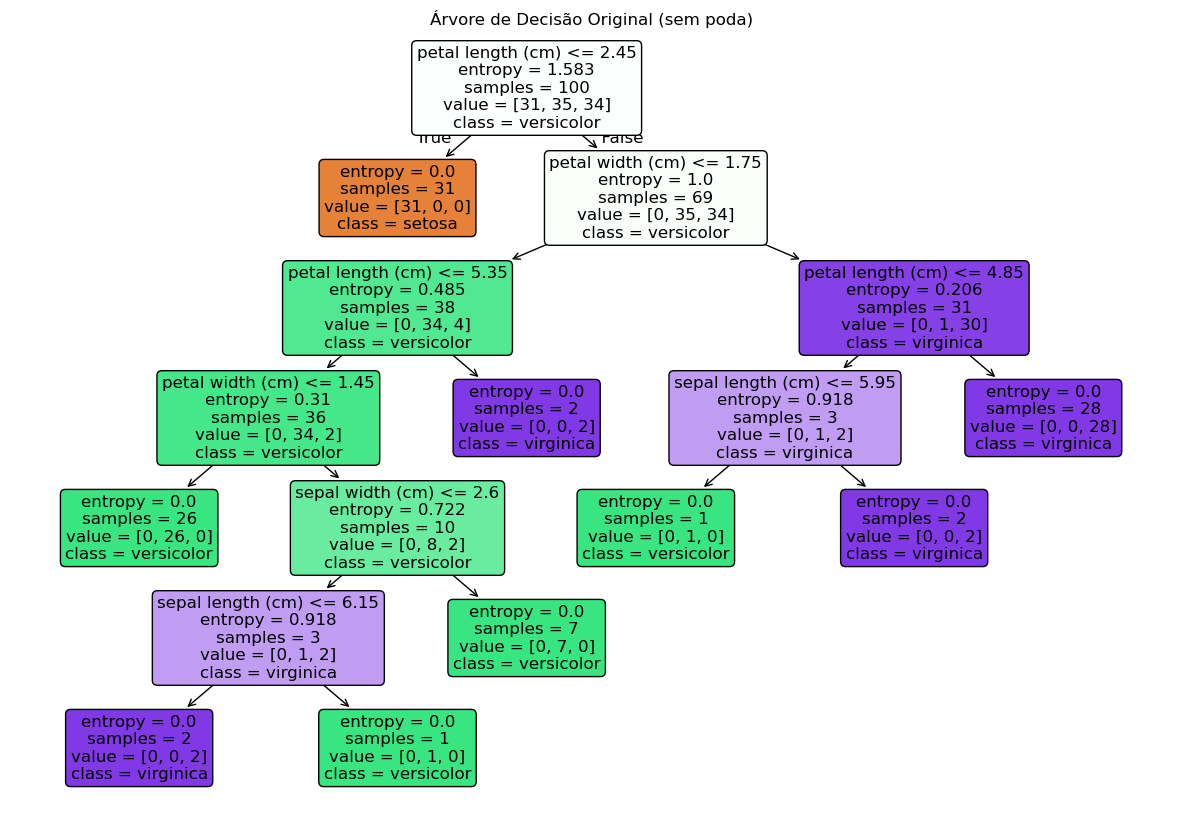

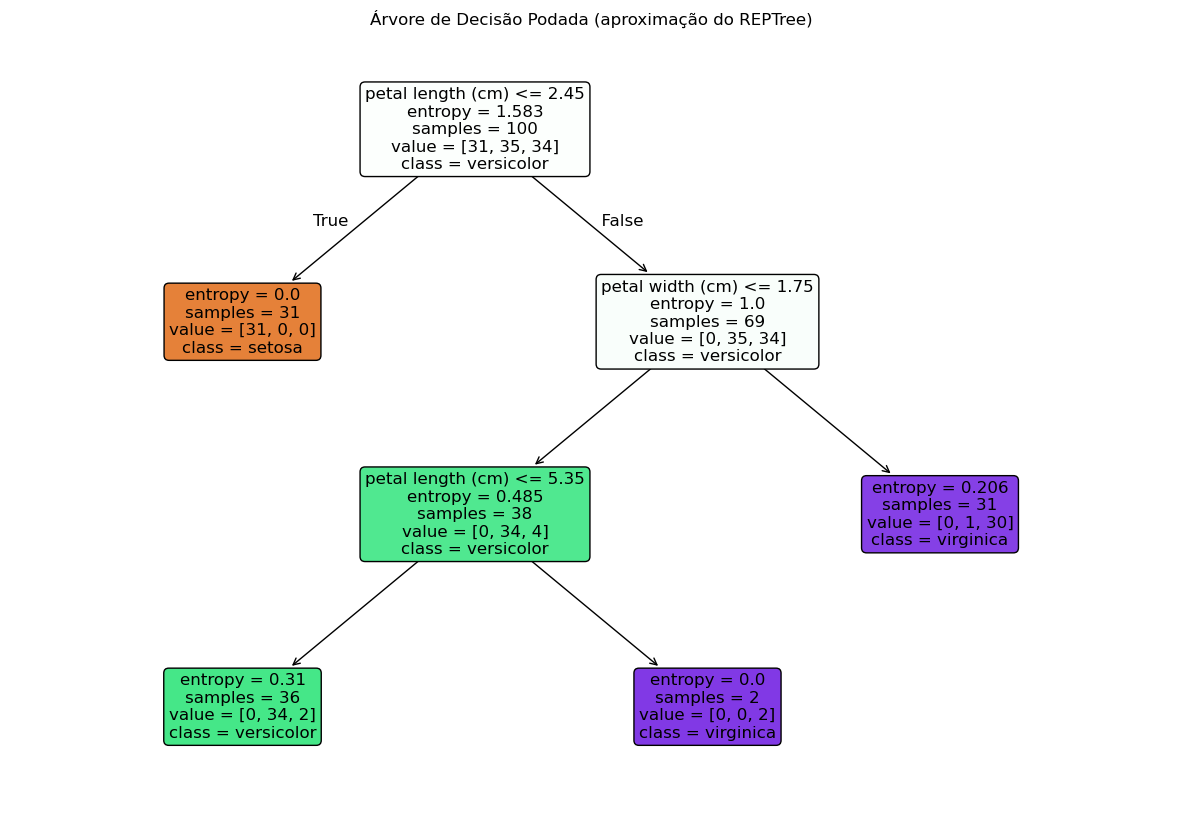

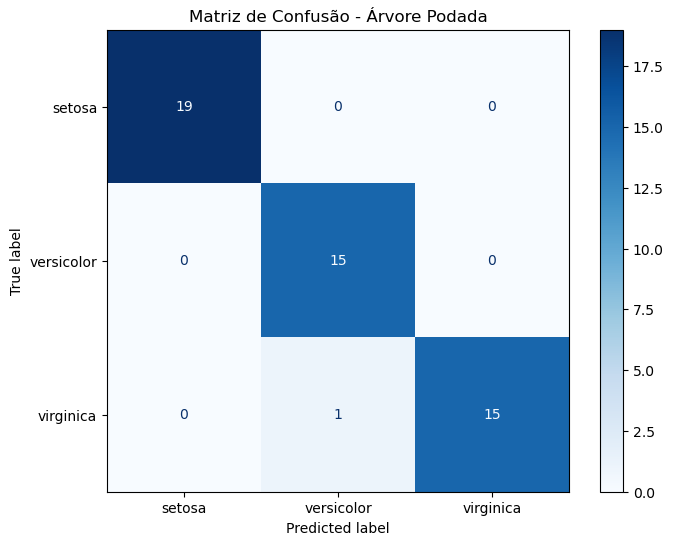

In [4]:
# ----- PARTE 3: Treinar a árvore podada final e comparar com a original -----
modelo_podado = DecisionTreeClassifier(criterion='entropy', ccp_alpha=melhor_alpha, random_state=42)
modelo_podado.fit(X_train, y_train)
previsoes_podado = modelo_podado.predict(X_test)
precisao_podado = accuracy_score(y_test, previsoes_podado)

# Árvore original (sem poda) para servir de referência na comparação
modelo_original = DecisionTreeClassifier(criterion='entropy', random_state=42)
modelo_original.fit(X_train, y_train)
previsoes_original = modelo_original.predict(X_test)
precisao_original = accuracy_score(y_test, previsoes_original)

# Comparação direta
print("="*50)
print("COMPARAÇÃO: Árvore Original vs Árvore Podada")
print("="*50)
print(f"Árvore Original (sem poda):")
print(f"  - Profundidade: {modelo_original.get_depth()}")
print(f"  - Nº de folhas: {modelo_original.get_n_leaves()}")
print(f"  - Acurácia no teste: {precisao_original * 100:.2f}%")
print(f"\nÁrvore Podada (ccp_alpha={melhor_alpha:.4f}):")
print(f"  - Profundidade: {modelo_podado.get_depth()}")
print(f"  - Nº de folhas: {modelo_podado.get_n_leaves()}")
print(f"  - Acurácia no teste: {precisao_podado * 100:.2f}%")

# Visualizar a árvore original
plt.figure(figsize=(15, 10))
plot_tree(modelo_original,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Árvore de Decisão Original (sem poda)")
plt.show()

# Visualizar a árvore podada
plt.figure(figsize=(15, 10))
plot_tree(modelo_podado,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Árvore de Decisão Podada (aproximação do REPTree)")
plt.show()

# Matriz de confusão da árvore podada
cm_podado = confusion_matrix(y_test, previsoes_podado)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_podado, display_labels=iris.target_names)
disp.plot(cmap='Blues', ax=ax)
plt.title("Matriz de Confusão - Árvore Podada")
plt.show()